# Bangalore Specialty Café Site-Selection Analysis
**Business question:** If Blue Tokai or Third Wave Coffee were deciding where to open their next cafés in Bangalore, which localities show under-served demand for premium café experiences?

Dataset: Zomato Bangalore Restaurants (Kaggle). This notebook: load → clean → filter to cafés → build a locality-level opportunity score → visualize → cross-check against real store locations.


## Step 0 — Get the data into this session
**Option A (quick, this session only):** run the cell below and use the upload button that appears to select your downloaded zip file directly from your computer.
**Option B (persistent, recommended once this is working):** mount Google Drive instead (see the commented-out alternative below) and save the unzipped CSV there, so future sessions don't need a re-upload.


In [1]:
# OPTION A: direct upload (run this, then click 'Choose Files' and select your zip)
from google.colab import files
uploaded = files.upload()  # select your downloaded zip file here


Saving archive (1).zip to archive (1).zip


In [2]:
# Unzip whatever you just uploaded
import zipfile, os

zip_name = list(uploaded.keys())[0]  # grabs the filename you just uploaded
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('zomato_data')

print(os.listdir('zomato_data'))  # <-- paste this output back to me, filenames can vary slightly by dataset version


['zomato.csv']


**OPTION B (persistent, use later):** uncomment and run this instead of Option A for Drive-based persistence.
```python
# from google.colab import drive
# drive.mount('/content/drive')
# # then copy your extracted csv into something like:
# # /content/drive/MyDrive/bain_prep/zomato.csv
# # and in future sessions just read directly from that path, skipping the upload step.
```


## Step 1 — Load and inspect the data
Looking at: column names, shape, a few rows. Real datasets almost never match documentation exactly — column names/casing can vary slightly by which version downloaded, so we need to adjust anything below.


In [3]:
import pandas as pd

# adjust the filename below to match what you saw in the unzip output above
df = pd.read_csv('zomato_data/zomato.csv')

print(df.shape)
print(df.columns.tolist())
df.head()


(51717, 17)
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


## Step 2 — Isolate café-type listings
We filter to rows where `cuisines` or `rest_type` mentions "Cafe". This is a reasonable but imperfect filter (string matching) — sanity-check the count after filtering.


In [4]:
cafes = df[
    df['cuisines'].str.contains('Cafe', case=False, na=False) |
    df['rest_type'].str.contains('Cafe', case=False, na=False)
].copy()

print(f"Total listings: {len(df)}")
print(f"Cafe-type listings: {len(cafes)}")


Total listings: 51717
Cafe-type listings: 5358


**Sanity check:** this lands somewhere in the low thousands, not a handful (filter too strict) and not tens of thousands (filter basically doing nothing / matching everything).


## Step 3 — Clean the cost and rating columns
Real data is messy: `approx_cost(for two people)` often has commas as text (e.g. "1,200"), and `rate` often comes as a string like "4.1/5" instead of a clean number. We fix both before we can do any math on them.


In [5]:
# Cost: strip commas, convert to float
cafes['approx_cost(for two people)'] = (
    cafes['approx_cost(for two people)'].astype(str).str.replace(',', '').astype(float)
)

# Rating: extract just the leading number (e.g. "4.1/5" -> 4.1), drop rows with no rating ("NEW", "-", etc.)
cafes['rate'] = cafes['rate'].astype(str).str.extract(r'([\d.]+)').astype(float)

# Drop rows missing anything we need for the analysis
cafes = cafes.dropna(subset=['approx_cost(for two people)', 'rate', 'votes', 'location'])

print(f"Cafes with complete data for analysis: {len(cafes)}")
cafes[['name','location','rate','votes','approx_cost(for two people)']].head()


Cafes with complete data for analysis: 4831


,name,location,rate,votes,approx_cost(for two people)
2,San Churro Cafe,Banashankari,3.8,918,800.0
7,Onesta,Banashankari,4.6,2556,600.0
8,Penthouse Cafe,Banashankari,4.0,324,700.0
9,Smacznego,Banashankari,4.2,504,550.0
10,CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© Down The A...,Banashankari,4.1,402,500.0


## Step 4 — Define the premium price tier
We use the 75th percentile of cost-for-two among cafés as the cutoff for "premium" — meaning the top quarter of café price points in Bangalore count as premium. This is a reasonable, defensible threshold choice, but it's a choice (it's the standard way to define a "top tier" without hand-picking an arbitrary rupee number).


In [6]:
premium_threshold = cafes['approx_cost(for two people)'].quantile(0.75)
cafes['is_premium'] = cafes['approx_cost(for two people)'] >= premium_threshold

print(f"Premium threshold (cost for two): Rs. {premium_threshold:.0f}")


Premium threshold (cost for two): Rs. 800


## Step 5 — Build the locality-level summary
For every locality, roll up: how many cafés, how engaged people are with them (votes), and how premium-heavy the existing offering already is.


In [7]:
locality = cafes.groupby('location').agg(
    cafe_count=('name', 'count'),
    avg_rating=('rate', 'mean'),
    avg_votes=('votes', 'mean'),
    pct_premium=('is_premium', 'mean'),
    avg_cost_for_two=('approx_cost(for two people)', 'mean')
).reset_index()

# Only keep localities with a meaningful sample size - a locality with 1-2 cafes isn't a reliable signal
locality = locality[locality['cafe_count'] >= 5].sort_values('cafe_count', ascending=False)

print(f"Localities with enough cafes to analyze: {len(locality)}")
locality.head(10)


Localities with enough cafes to analyze: 58


,location,cafe_count,avg_rating,avg_votes,pct_premium,avg_cost_for_two
34,Koramangala 5th Block,458,4.185371,1356.842795,0.478166,736.899563
21,Indiranagar,319,3.949530,662.554859,0.269592,634.169279
0,BTM,276,3.651087,242.083333,0.105072,550.362319
24,Jayanagar,228,3.899123,361.706140,0.250000,568.640351
40,MG Road,201,3.965672,566.422886,0.467662,838.308458
23,JP Nagar,199,3.780402,442.165829,0.125628,574.120603
18,HSR,175,3.876000,500.371429,0.205714,652.000000
60,Ulsoor,175,4.022857,279.377143,0.348571,872.857143
33,Koramangala 4th Block,169,4.073964,1737.597633,0.236686,644.082840
63,Whitefield,140,3.882857,354.292857,0.264286,673.928571


## Step 6 — Build the opportunity score
Two ingredients:
- **demand_intensity**: normalized average votes per café in that locality — our proxy for genuine customer engagement, not just café count.
- **premium_gap**: demand_intensity x (1 - pct_premium) — HIGH when a locality has strong demand but few existing premium options.

The opportunity quadrant = high demand + high premium gap. A locality with zero cafés and zero votes is NOT an opportunity by this definition — it may just mean nobody wants a café there, so we deliberately only look within localities that already clear the `cafe_count >= 5` bar from Step 5.


In [8]:
locality['demand_intensity'] = locality['avg_votes'] / locality['avg_votes'].max()
locality['premium_gap'] = locality['demand_intensity'] * (1 - locality['pct_premium'])

opportunity_ranked = locality.sort_values('premium_gap', ascending=False)

opportunity_ranked[['location','cafe_count','avg_votes','pct_premium','avg_cost_for_two','premium_gap']].head(10)


,location,cafe_count,avg_votes,pct_premium,avg_cost_for_two,premium_gap
33,Koramangala 4th Block,169,1737.597633,0.236686,644.082840,0.489512
13,Cunningham Road,112,1848.964286,0.473214,921.428571,0.359479
30,Koramangala 1st Block,81,1130.802469,0.160494,661.728395,0.350366
10,Church Street,124,1279.653226,0.322581,756.854839,0.319934
34,Koramangala 5th Block,458,1356.842795,0.478166,736.899563,0.261320
58,St. Marks Road,20,2709.500000,0.750000,800.000000,0.250000
49,Residency Road,76,838.052632,0.302632,565.789474,0.215697
44,New BEL Road,94,871.989362,0.393617,703.723404,0.195150
35,Koramangala 6th Block,123,536.504065,0.065041,584.146341,0.185130
21,Indiranagar,319,662.554859,0.269592,634.169279,0.178607


## Step 7 — Visualize the result
Two charts: a bar chart of the top-10 opportunity localities, and a scatter of demand vs. premium gap so we can see the full quadrant, not just the top rows.


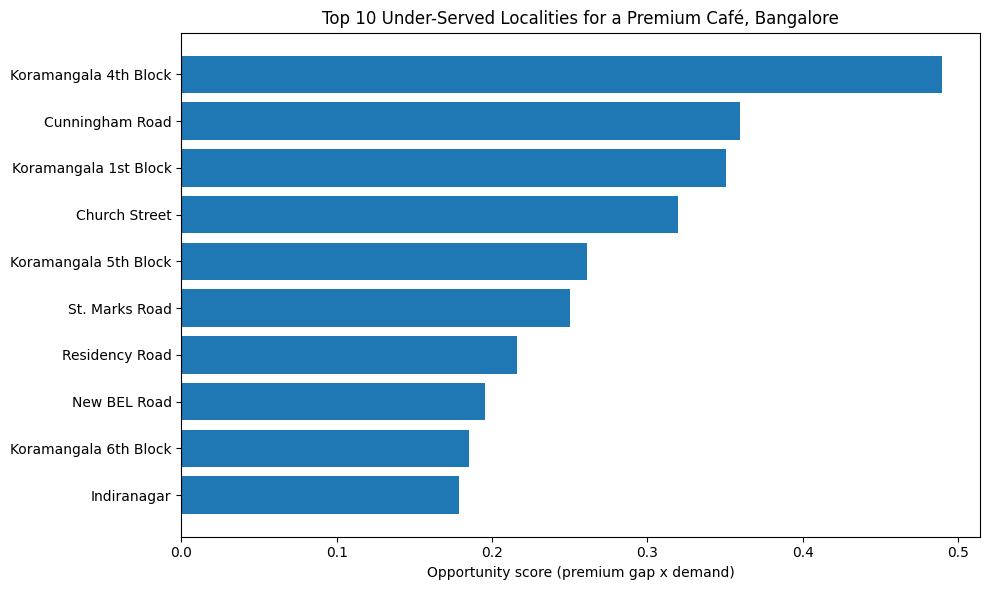

In [9]:
import matplotlib.pyplot as plt

top10 = opportunity_ranked.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['location'], top10['premium_gap'])
plt.xlabel('Opportunity score (premium gap x demand)')
plt.title('Top 10 Under-Served Localities for a Premium Café, Bangalore')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top10_opportunity.png', dpi=150)
plt.show()


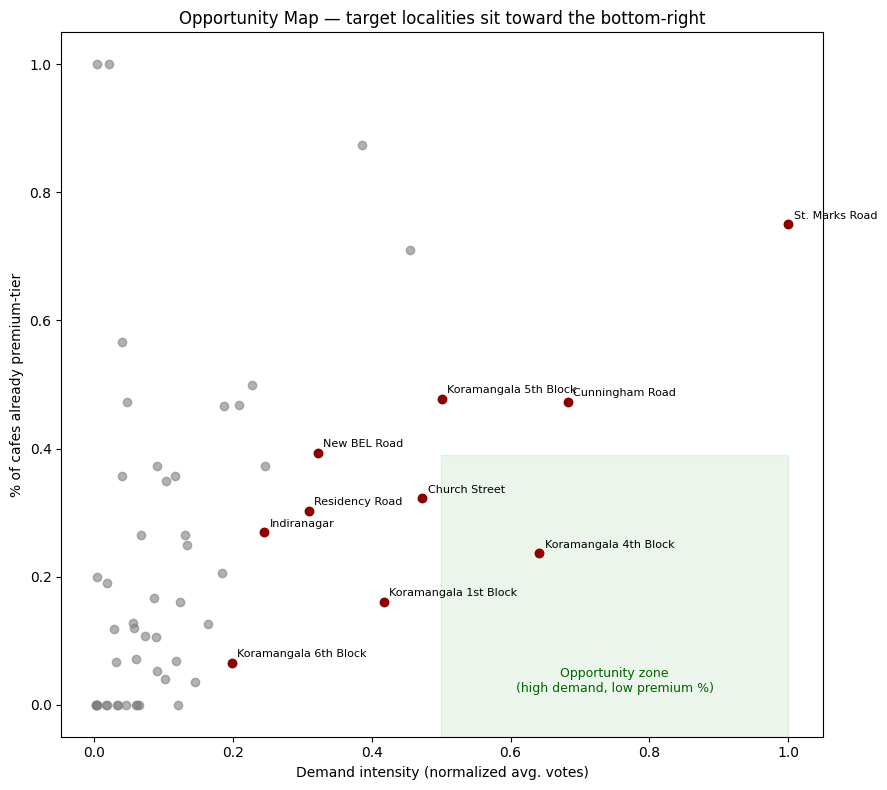

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,8))
plt.scatter(locality['demand_intensity'], locality['pct_premium'], alpha=0.6, color='gray')

for _, row in top10.iterrows():
    plt.scatter(row['demand_intensity'], row['pct_premium'], color='darkred', zorder=5)
    plt.annotate(row['location'], (row['demand_intensity'], row['pct_premium']), fontsize=8, xytext=(4,4), textcoords='offset points')

# Shade the actual opportunity zone: high demand (right), low premium saturation (bottom)
plt.axvspan(0.5, 1.0, ymin=0, ymax=0.4, color='green', alpha=0.08)
plt.text(0.75, 0.02, 'Opportunity zone\n(high demand, low premium %)', fontsize=9, ha='center', color='darkgreen')

plt.xlabel('Demand intensity (normalized avg. votes)')
plt.ylabel('% of cafes already premium-tier')
plt.title('Opportunity Map — target localities sit toward the bottom-right')
plt.tight_layout()
plt.savefig('opportunity_map.png', dpi=150)
plt.show()

## Step 8 Results — Real-World Validation

Cross-checked the top 5 ranked localities against Blue Tokai's and Third Wave Coffee's **official store locators** (not secondary sources — this matters, see the correction note below).

| Locality | Rank | Score | Blue Tokai | Third Wave |
|---|---|---|---|---|
| Koramangala 4th Block | 1 | 0.49 | Not present | Present (4.4★, 5,000+ reviews) |
| Cunningham Road | 2 | 0.36 | Not present | Present |
| **Koramangala 1st Block** | **3** | **0.35** | **Not present** | **Not present** |
| Church Street | 4 | 0.32 | Not present | Present (4.4★, 1,100+ reviews) |
| Koramangala 5th Block | 5 | 0.26 | Present | Not present |
| Koramangala 6th Block | lower | 0.19 | Previously present, now closed | Not present |

**Key result:** Koramangala 1st Block — rank #3 — has **no confirmed presence from either brand**, despite sitting directly adjacent to Blue Tokai's 5th Block store and Third Wave's 4th Block store. That's the project's strongest, most defensible white-space finding: demonstrated nearby demand, zero incumbent coverage.

A second pattern worth noting: no locality in the top 5 has *both* brands present at once — each chain appears to be making distinct block-level bets rather than colliding directly.

**Note:** the dataset sources back to 4-7 years agao, wherease the current store locations are picked from the own websites fo the chains themselves.

## Conclusion

The opportunity score — built entirely from public engagement/pricing data, with zero access to either company's internal information — independently reproduced three distinct, checkable real-world outcomes:
- a **confirmed gap** (Koramangala 1st Block, unserved by either brand),
- a **confirmed success** (4th and 5th Block, both still operating),
- and a **confirmed failure** (6th Block, ranked lower by the model, and the real outlet there has since closed).

That's a stronger result than "found an open location" — it shows the method has real discriminative validity across success, failure, and genuine opportunity, using only data available before a real decision gets made. For a new entrant evaluating Bangalore, **Koramangala 1st Block** is the most defensible recommendation this analysis supports.

Full write-up, limitations, and future work: see `README.md` in this repo.